In [1]:
from resources.imports import *

In [2]:
from resources.MLdata import *
from resources.MLfunc import *
from resources.MLmodels import MODEL, Autoencoder

In [3]:
DAT = DATA(path=1, load=True, LAT="FCC", dis="disNodes", dN=20, model="MLP", format=1)
DAT.train_in.shape, DAT.val_in.shape, DAT.test_in.shape

((353, 900), (63, 900), (74, 900))

# Principal Component Analysis (PCA)

In [4]:
X_data = np.concatenate((DAT.train_in, DAT.val_in, DAT.test_in))
X_data = X_data.reshape(X_data.shape[0], X_data.shape[1]//2, 2)
X_data = X_data[:,:,0]
X_data.shape

(490, 450)

c:\Users\exy053\OneDrive - Queen Mary, University of London\Documents\Research\p1-LatticeFractureToughness\p1git-Lattices\code\resources\MLdata.py:283: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


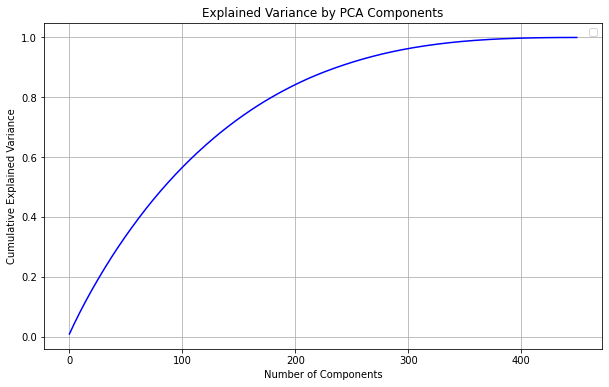

Number of components to capture 50% variance: 85
Number of components to capture 80% variance: 180
Number of components to capture 90% variance: 238
Number of components to capture 95% variance: 284
Number of components to capture 100% variance: 450


In [5]:
pca = PCA_()
pca.fit(data=X_data, scale=True, verbose=True)

In [6]:
X_reduced = pca.reduce(data=X_data, scale=True, accuracy=0.999999, n_components=None, verbose=True)
# pd.DataFrame(pca.final_pca.get_covariance())

Original data shape: (490, 450)
Reduced data shape: (490, 450)


In [7]:
X_recon = pca.reconstruct(data=X_reduced, scale=True)

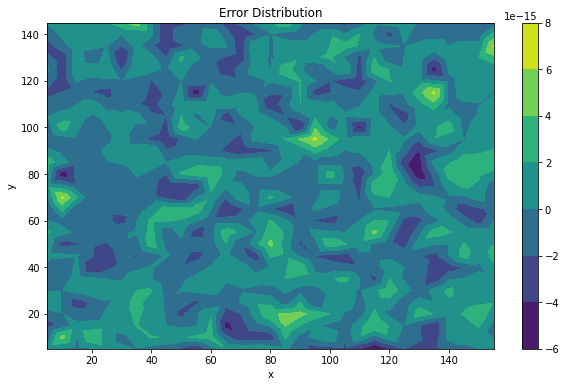

2.1000990082201812e-15

In [8]:
indx = 203
xy = 0

plt_outputs = X_recon[indx]#.reshape(X_recon.shape[1]//2, 2)[:,xy]
truth = X_data[indx]#.reshape(X_recon.shape[1]//2,2)[:,xy]

plot_Distribution(DAT.train_in1, plt_outputs, truth=truth)

np.sqrt(np.mean((plt_outputs - truth) ** 2))

# Autoencoder

In [4]:
X_data = np.concatenate((DAT.train_inST, DAT.val_inST, DAT.test_inST))
X_data = X_data.reshape(X_data.shape[0], X_data.shape[1]//2, 2)
X_data = X_data[:,:,0]
X_data.shape

(490, 450)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_size = X_data.shape[-1] #DAT.train_in.shape[-1]
h_size = []
latent_size = 100

BATCH_SIZE = 1
LEARNING_RATE = 1e-3

Using device: cpu


In [6]:
trainDS = Dataset_(X_data, X_data)
testDS = Dataset_(X_data, X_data)

train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=testDS, batch_size=BATCH_SIZE, shuffle=False)

In [8]:
ENC = MODEL(
    typ="MLP",
    model=Autoencoder(in_size, latent_size, h_size, block="mlp").to(device), 
    lossf=nn.MSELoss(),
    opt=("adam", 0),
    batch=BATCH_SIZE,
    lr=LEARNING_RATE,
    data=DAT,
    train_dataloader=train_dataloader, 
    val_dataloader=None, 
    test_dataloader=test_dataloader,
    scheduler=("min", 0.7, 10, 1e-4, True), 
    earlyStop=None, #EarlyStopping(patience=50, min_delta=1e-4, verbose=True),
    w_init=weights_init,
)

print(summary(ENC.model, input_size=(BATCH_SIZE, in_size)))

Layer (type:depth-idx)                   Output Shape              Param #
Autoencoder                              [1, 450]                  --
├─MLP: 1-1                               [1, 100]                  --
│    └─Linear: 2-1                       [1, 100]                  45,100
├─MLP: 1-2                               [1, 450]                  --
│    └─Linear: 2-2                       [1, 450]                  45,450
Total params: 90,550
Trainable params: 90,550
Non-trainable params: 0
Total mult-adds (M): 0.09
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.36
Estimated Total Size (MB): 0.37


c:\Programs\Python39\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:
latents = np.flip(np.linspace(50, in_size-20, (in_size-20)//21, dtype=int))
min_latent = 0
for latent in latents:
    print(f"Starting training attempt with latent size: {latent}")
    
    ENC = MODEL(
        typ="MLP",
        model=Autoencoder(in_size, latent, h_size, block="mlp").to(device), 
        lossf=nn.MSELoss(),
        opt=("adam", 0),
        batch=BATCH_SIZE,
        lr=LEARNING_RATE,
        data=DAT,
        train_dataloader=train_dataloader, 
        val_dataloader=None, 
        test_dataloader=test_dataloader,
        scheduler=("min", 0.7, 10, 1e-4, True), 
        earlyStop=None, #EarlyStopping(patience=50, min_delta=1e-4, verbose=True),
        w_init=weights_init,
    )

    # print(summary(ENC.model, input_size=(BATCH_SIZE, in_size)))

    ENC.train(n_epochs=500, verbose=50, plot=True, RMSEtarget=True)
    
    if ENC.best_rmse[0] is True:
        min_latent = latent
    else:
        break

print(f"Best Latent Dimension Tested: {min_latent}")

In [ ]:
ENC.train(n_epochs=500, verbose=10, plot=True, RMSEtarget=True)

Best prediction: 251, Worst prediction: 162


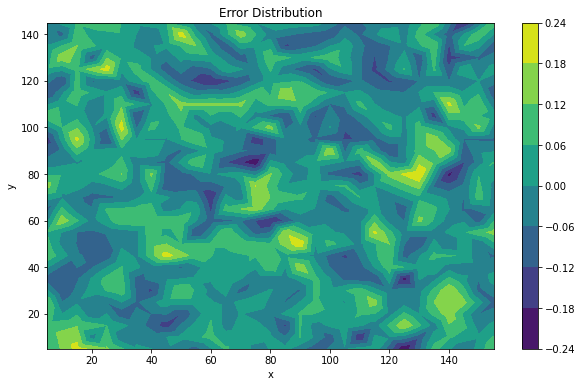

0.09280807

In [40]:
ENC.predict(stand="in", plot=False, test_dataloader=ENC.train_dataloader)

indx = 51      # ADAPT CLASS (model or data) TO AUTOENCODER STRUCTURES
xy = 0

plt_outputs = ENC.test_outputs[indx] #.reshape(X_recon.shape[1]//2, 2)[:,xy]
truth = ENC.truth[indx] #.reshape(X_recon.shape[1]//2,2)[:,xy]

plot_Distribution(ENC.data.train_in1, plt_outputs, truth=truth, typ="contour")

np.mean(np.sqrt(np.mean(np.square(ENC.test_outputs - ENC.truth), axis=1)))

In [52]:
def objective(trial):
    # lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    # batch_size = trial.suggest_categorical('batch_size', [1, 2, 4])
    latent_size = trial.suggest_int('latent_size', 50, 500, step=10)

    model_instance = MODEL(
        typ="MLP",
        model=Autoencoder(in_size, latent_size, h_size, block="mlp").to(device),
        lossf=nn.MSELoss(),
        opt=("adam", 0),
        batch=BATCH_SIZE,
        lr=LEARNING_RATE,
        data=DAT,
        train_dataloader=train_dataloader,
        val_dataloader=None,
        scheduler=("min", 0.7, 10, 1e-4, True),
        earlyStop=EarlyStopping(patience=10, verbose=False),
        w_init=weights_init,
        optTrial=trial  # Pass the trial object here
    )

    model_instance.train(n_epochs=1000, verbose=50)
    return model_instance.best_loss

study = hOpt(objective, n_trials=20, prnt=True, save=False, path="models/", name="Autoencoder-DimReduction")

[I 2025-06-20 10:56:42,072] A new study created in memory with name: no-name-e5f39627-7b7a-428f-8f2f-9abb44703ab9


Epoch: 1 - Loss: 1.7350435256958008
Epoch: 50 - Loss: 0.42047566175460815


[I 2025-06-20 10:57:15,331] Trial 0 finished with value: 0.37034550309181213 and parameters: {'latent_size': 470}. Best is trial 0 with value: 0.37034550309181213.


Best Epoch: 72, with loss 0.37034550309181213
Epoch: 1 - Loss: 1.9050889015197754
Epoch: 50 - Loss: 0.3338008522987366


[I 2025-06-20 10:57:34,178] Trial 1 finished with value: 0.3063221275806427 and parameters: {'latent_size': 370}. Best is trial 1 with value: 0.3063221275806427.


...

Epoch: 1 - Loss: 1.9267117977142334


[I 2025-06-20 10:58:48,231] Trial 17 pruned. 
[I 2025-06-20 10:58:48,518] Trial 18 pruned. 


Epoch: 1 - Loss: 1.9991337060928345


[I 2025-06-20 10:58:49,015] Trial 19 pruned. 



 Optimization Finished. Study statistics: 
  Number of finished trials: 20

Best trial 
 Loss: 0.2698553800582886

 Hyperparameters:
  latent_size: 330


In [16]:
load_bestParams(path="models/", name="Autoencoder-DimReduction")

{'latent_size': 280}